**Importing Libraries**

In [7]:
import pandas as pd
import numpy as np
import re
import nltk

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [8]:
nltk.download('stopwords')        #download nltk resources

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

**Loading the Dataset**

In [9]:
df = pd.read_csv("/flipkart.csv")

In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2304, 4)


In [11]:
df.head()

,Unnamed: 0,Product_name,Review,Rating
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


In [12]:
df.tail()

,Unnamed: 0,Product_name,Review,Rating
2299,2299,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,"Great display, accurate colours at this price ...",5
2300,2300,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Superb monitor first brought 1 used for 2 mont...,5
2301,2301,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Awesome,5
2302,2302,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Only one issue with adapter,5
2303,2303,MSI 27 inch Full HD IPS Panel Monitor (PRO MP2...,Worth the money u spend for this monitor Great...,5


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    2304 non-null   int64 
 1   Product_name  2304 non-null   object
 2   Review        2304 non-null   object
 3   Rating        2304 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 72.1+ KB


In [14]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Unnamed: 0      0
Product_name    0
Review          0
Rating          0
dtype: int64


**Data Cleaning**

In [15]:
df.shape

(2304, 4)

In [16]:
df.dropna(subset=['Review', 'Rating'], inplace=True)

df['Rating'] = df['Rating'].astype(int)

print("\nDataset Shape After Cleaning:", df.shape)



Dataset Shape After Cleaning: (2304, 4)


**Performing EDA**

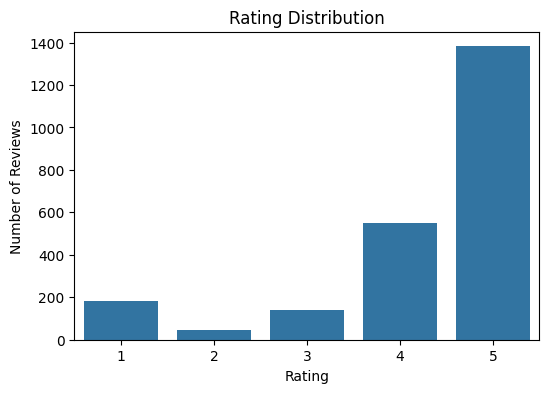

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='Rating', data=df)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

**Sentiment Label Creation**

Logic:

Rating 4 & 5 → Positive (1)

Rating 1 & 2 → Negative (0)

Rating 3 → Neutral

In [18]:
df = df[df['Rating'] != 3]

df['Sentiment'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)

print(df['Sentiment'].value_counts())

Sentiment
1    1934
0     230
Name: count, dtype: int64


**Sentiment Visualization**

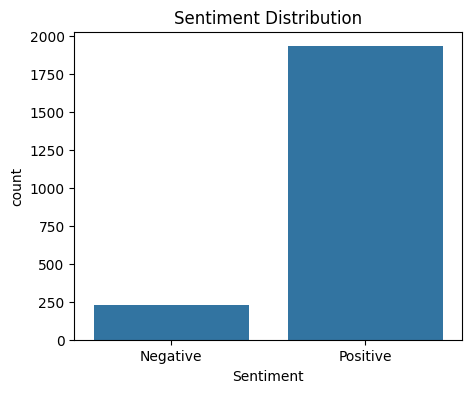

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x='Sentiment', data=df)
plt.xticks([0,1], ['Negative', 'Positive'])
plt.title("Sentiment Distribution")
plt.show()

**Text Preprocessing**

In [20]:
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

def clean_review(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_review'] = df['Review'].apply(clean_review)

**Outlier Detection**

In [21]:
df['review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))      #Text-based Outliers = Extremely Short or Long Reviews

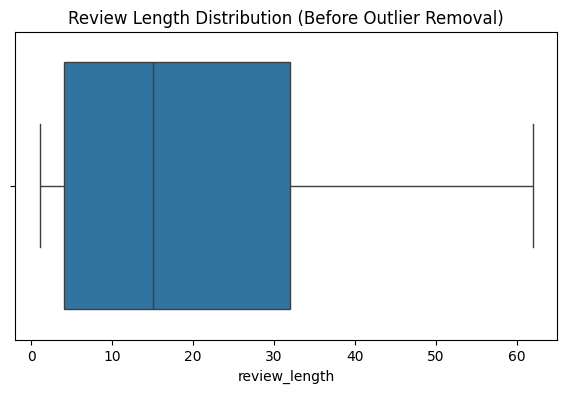

In [22]:
plt.figure(figsize=(7,4))                        #Visualizing review length outliers
sns.boxplot(x=df['review_length'])
plt.title("Review Length Distribution (Before Outlier Removal)")
plt.show()

In [23]:
min_length = 3                                    #Removing Outliers
max_length = df['review_length'].quantile(0.95)

df = df[
    (df['review_length'] >= min_length) &
    (df['review_length'] <= max_length)
]

print("Shape After Outlier Removal:", df.shape)

Shape After Outlier Removal: (1669, 7)


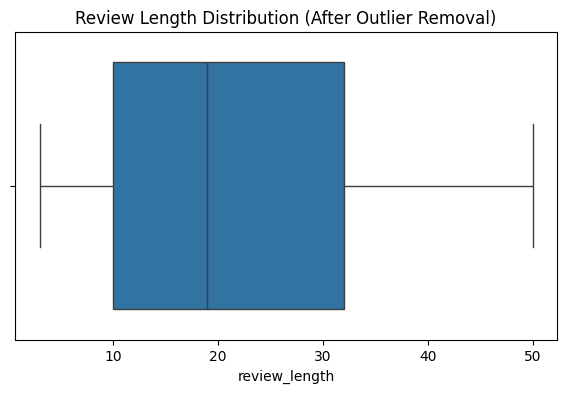

In [24]:
plt.figure(figsize=(7,4))               #Visualizing after cleaning
sns.boxplot(x=df['review_length'])
plt.title("Review Length Distribution (After Outlier Removal)")
plt.show()

**Train-Test Split**

In [25]:
X = df['cleaned_review']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Feature Extraction using TF-IDF**

In [26]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Shape:", X_train_tfidf.shape)

TF-IDF Shape: (1335, 3142)


**Model Training**

In [27]:
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train_tfidf, y_train)

LogisticRegression(random_state=42, solver='liblinear')

**Model Evaluation**

In [28]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 91.92 %


In [29]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.29      0.45        38
    Positive       0.92      1.00      0.96       296

    accuracy                           0.92       334
   macro avg       0.96      0.64      0.70       334
weighted avg       0.93      0.92      0.90       334



**Using Confusion Matrix**

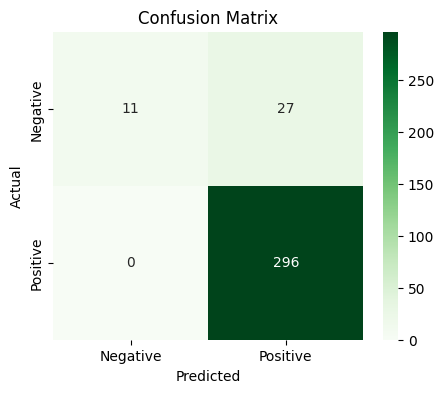

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Predicting the model**

In [31]:
def predict_sentiment(review):
    cleaned = clean_review(review)
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0][prediction]

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("\nReview:", review)
    print("Predicted Sentiment:", sentiment)
    print("Confidence:", round(probability * 100, 2), "%")
    print("Model Accuracy:", round(accuracy * 100, 2), "%")

In [32]:
predict_sentiment("This product is excellent and totally worth the price.")
predict_sentiment("Worst product ever, very poor quality.")
predict_sentiment("Delivery was fast but product quality is average.")


Review: This product is excellent and totally worth the price.
Predicted Sentiment: Positive
Confidence: 91.62 %
Model Accuracy: 91.92 %

Review: Worst product ever, very poor quality.
Predicted Sentiment: Negative
Confidence: 72.92 %
Model Accuracy: 91.92 %

Review: Delivery was fast but product quality is average.
Predicted Sentiment: Positive
Confidence: 91.93 %
Model Accuracy: 91.92 %
